<a href="https://colab.research.google.com/github/kkumarisfdc/Kiran-s_Portfolio/blob/main/Day_23_Random_forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np



In [ ]:
from sklearn.datasets import load_breast_cancer

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from sklearn.metrics import roc_curve
from sklearn.metrics import auc

import matplotlib.pyplot as plt


In [ ]:
data = load_breast_cancer()

x=data.data
y = data.target


In [ ]:
print(data.feature_names)

['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


In [ ]:
X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
LR = LogisticRegression(
    max_iter=5000
)
LR.fit(X_train,y_train)

LogisticRegression(max_iter=5000)

In [ ]:
LR  = LogisticRegression(
    max_iter=5000
)
LR.fit(X_train,y_train)

LogisticRegression(max_iter=5000)

In [ ]:
RF  = RandomForestClassifier()
RF.fit(X_train,y_train)
rf_pred  = RF.predict(X_test)

In [ ]:
lr_pred = LR.predict(X_test)
lr_acc = accuracy_score(y_test,lr_pred)
rf_acc = accuracy_score(y_test,rf_pred)
print("Logistic Regression")
print(lr_acc)
print()
print("Random Forest")
print(rf_acc)

Logistic Regression
0.956140350877193

Random Forest
0.9649122807017544


In [ ]:
lr_scores = cross_val_score(LR,x,y,cv=5)
print(lr_scores.mean())
rf_scores = cross_val_score(RF,x,y,cv=5)

0.9507995652848935


In [ ]:
importance  = RF.feature_importances_


In [ ]:
feature_df = pd.DataFrame(
    {
        "Features":data.feature_names,
        "Importance":importance
    }
)

In [ ]:
feature_df = feature_df.sort_values(by="Importance",ascending=False)
feature_df.head()

,Features,Importance
22,worst perimeter,0.174060
7,mean concave points,0.158474
20,worst radius,0.124097
27,worst concave points,0.068033
23,worst area,0.062439


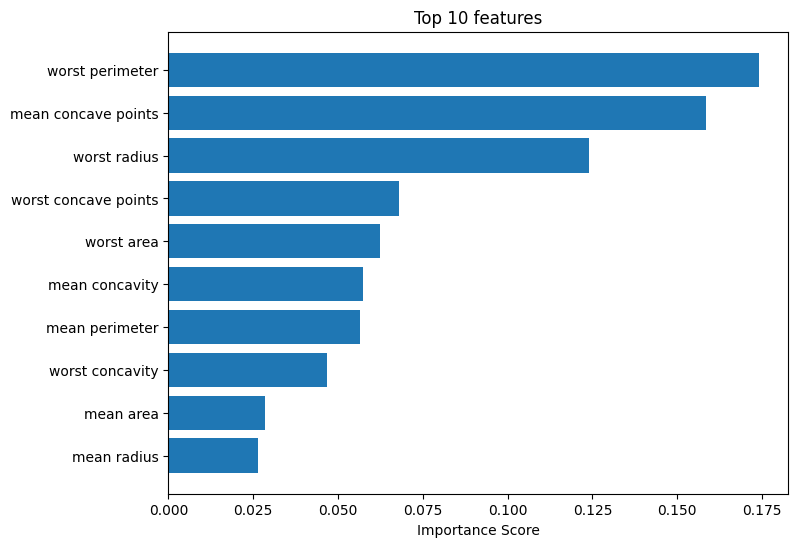

In [ ]:
plt.figure(figsize=(8,6))
plt.barh(feature_df["Features"][:10],feature_df["Importance"][:10])
plt.xlabel("Importance Score")

plt.title("Top 10 features")
plt.gca().invert_yaxis()
plt.show()